In [2]:
"""Task 1"""


#importing necessary libraries
import pandas as pd
import requests

In [3]:
#reading username from a textfile - frostmet.no
client_id = open("C:/Users/danie/Documents/NMBU 4.år/Inf 201/W41_42/Client_id_frostmet.txt").read().strip()
print(client_id)

195aadb0-a0cf-4c77-9a8d-2c24e327f3f8


In [4]:
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources'   : 'SN17850',
    'elements'  : 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2026-01-01', 
}
# Set referencetime to a full year (1st jan. 25 -> 1st jan. 26) so that i can check temperature 31st december
# otherwise the range(DATA) is only day 0 to day 363, 364 days.

In [5]:
# request access to data from website
frost_response = requests.get(endpoint, parameters, auth = (client_id,""))
print(frost_response.status_code)
#print(frost_response.text)


200


In [6]:
frost_response = requests.get(endpoint, parameters, auth = (client_id,""))
assert frost_response.status_code == 200

for header_name, header_value in frost_response.headers.items():
    print(f'{header_name:16s}:{header_value}')

x-frost         :cache-status=hits:0/misses:0/noncacheable:1
cache-control   :max-age=-1
date            :Fri, 09 Oct 2026 10:53:17 GMT
content-type    :application/json
content-length  :319843


In [7]:
# Transform frost_response json file to python dictionary, list etc. with .json()-method
frost_payload = frost_response.json()
frost_payload.keys()

dict_keys(['@context', '@type', 'apiVersion', 'license', 'createdAt', 'queryTime', 'currentItemCount', 'itemsPerPage', 'offset', 'totalItemCount', 'currentLink', 'data'])

In [8]:
for payload_name, payload_value in frost_payload.items():
    if payload_name == 'data':
        continue
    print(f'{payload_name:20s} : {payload_value}')

@context             : https://frost.met.no/schema
@type                : ObservationResponse
apiVersion           : v0
license              : https://creativecommons.org/licenses/by/3.0/no/
createdAt            : 2026-10-09T10:53:17Z
queryTime            : 0.275
currentItemCount     : 365
itemsPerPage         : 365
offset               : 0
totalItemCount       : 365
currentLink          : https://frost.met.no/observations/v0.jsonld?sources=SN17850&elements=mean%28air_temperature+P1D%29&referencetime=2025-01-01%2F2026-01-01


In [9]:
frost_payload['data'][364]

{'sourceId': 'SN17850:0',
 'referenceTime': '2025-12-31T00:00:00.000Z',
 'observations': [{'elementId': 'mean(air_temperature P1D)',
   'value': -4.4,
   'unit': 'degC',
   'level': {'levelType': 'height_above_ground', 'unit': 'm', 'value': 2},
   'timeOffset': 'PT0H',
   'timeResolution': 'P1D',
   'timeSeriesId': 0,
   'performanceCategory': 'C',
   'exposureCategory': '1',
   'qualityCode': 0},
  {'elementId': 'mean(air_temperature P1D)',
   'value': -4.7,
   'unit': 'degC',
   'level': {'levelType': 'height_above_ground', 'unit': 'm', 'value': 2},
   'timeOffset': 'PT6H',
   'timeResolution': 'P1D',
   'timeSeriesId': 0,
   'performanceCategory': 'C',
   'exposureCategory': '1'}]}

In [10]:
# create a list that contains a dict of the timestamp and corresponding temperature
# use this to create a mean temperature dataframe that can be plotted.

temp_data = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Average daily temperature [C]': entry['observations'][0]['value']}
              for entry in frost_payload['data']]


In [11]:
# create a pandas dataframe to organize data

mean_temp_df = pd.DataFrame.from_records(temp_data).set_index('Time')
mean_temp_df[0:10]

,Average daily temperature [C]
Time,
2025-01-01 00:00:00+00:00,-5.2
2025-01-02 00:00:00+00:00,-11.5
2025-01-03 00:00:00+00:00,-8.9
2025-01-04 00:00:00+00:00,-15.5
2025-01-05 00:00:00+00:00,-12.5
2025-01-06 00:00:00+00:00,-3.8
2025-01-07 00:00:00+00:00,0.4
2025-01-08 00:00:00+00:00,-4.0
2025-01-09 00:00:00+00:00,-2.4


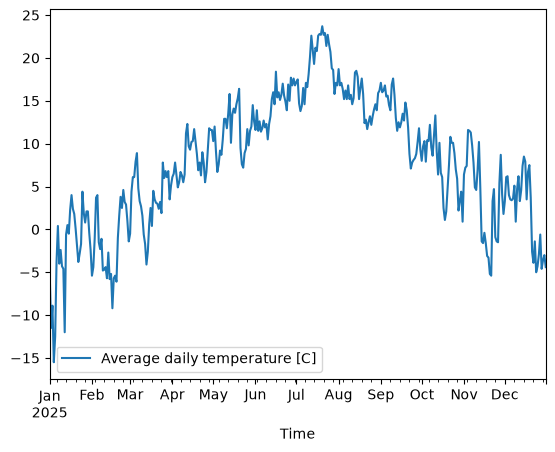

In [12]:
#Plot of the daily mean temperature

mean_plot = mean_temp_df.plot()


In [13]:
temp_data_test = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Average daily temperature [C]': entry['observations'][1]['value']}
              for entry in frost_payload['data']]
temp_data_test[:4]
# sjekker om vi får en endring i temperaturverdier om vi endrer indeksen til observations fra 0 til 1


[{'Time': Timestamp('2025-01-01 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -2.8},
 {'Time': Timestamp('2025-01-02 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -7.2},
 {'Time': Timestamp('2025-01-03 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -11},
 {'Time': Timestamp('2025-01-04 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -10.7}]

In [14]:
temp_data[:4]

[{'Time': Timestamp('2025-01-01 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -5.2},
 {'Time': Timestamp('2025-01-02 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -11.5},
 {'Time': Timestamp('2025-01-03 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -8.9},
 {'Time': Timestamp('2025-01-04 00:00:00+0000', tz='UTC'),
  'Average daily temperature [C]': -15.5}]

In [15]:
# creating variables for max, min, median and mean

min_temp = mean_temp_df['Average daily temperature [C]'].min()
max_temp = mean_temp_df['Average daily temperature [C]'].max()
mean_temp = mean_temp_df['Average daily temperature [C]'].mean()
median_temp = mean_temp_df['Average daily temperature [C]'].median()

print(f"""Summary table of daily mean temperatures measured on SN17850
    'Mean temperature'          :     {mean_temp:.2f}
    'Median temperature'        :     {median_temp:.2f}
    'Minimum mean daily temp'   :   {min_temp:.2f}
    'Maximum mean daily temp'   :    {max_temp:.2f} """)


Summary table of daily mean temperatures measured on SN17850
    'Mean temperature'          :     7.87
    'Median temperature'        :     8.30
    'Minimum mean daily temp'   :   -15.50
    'Maximum mean daily temp'   :    23.70 
